Loading text features...
  Feature matrix : (7102, 5001)
  Labels         : (array(['High', 'Low', 'Moderate'], dtype=object), array([1533, 1616, 3953]))

Train size : 5681   Test size : 1421

════════════════════════════════════════════════════════════
  MODEL TRAINING & EVALUATION
════════════════════════════════════════════════════════════

  Training: Logistic Regression
    CV  F1 (macro) : 0.8145 ± 0.0072
    Test F1 (macro): 0.8451
    Test Accuracy  : 0.8600

  Training: Linear SVM
    CV  F1 (macro) : 0.8500 ± 0.0058
    Test F1 (macro): 0.8781
    Test Accuracy  : 0.8916

  Training: Random Forest
    CV  F1 (macro) : 0.8269 ± 0.0142
    Test F1 (macro): 0.8508
    Test Accuracy  : 0.8698

  Training: Gradient Boosting
    CV  F1 (macro) : 0.8589 ± 0.0112
    Test F1 (macro): 0.8559
    Test Accuracy  : 0.8698

════════════════════════════════════════════════════════════
  WINNER : Linear SVM
  Test F1 (macro) : 0.8781
  Test Accuracy   : 0.8916
══════════════════════════════

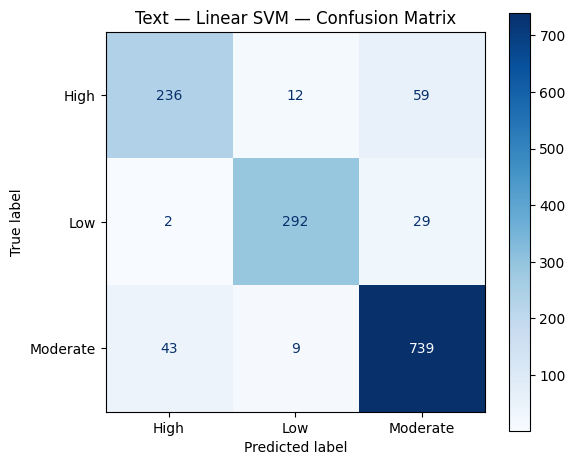


Model comparison:
              Model  CV F1  Test F1  Accuracy
Logistic Regression 0.8145   0.8451    0.8600
         Linear SVM 0.8500   0.8781    0.8916
      Random Forest 0.8269   0.8508    0.8698
  Gradient Boosting 0.8589   0.8559    0.8698


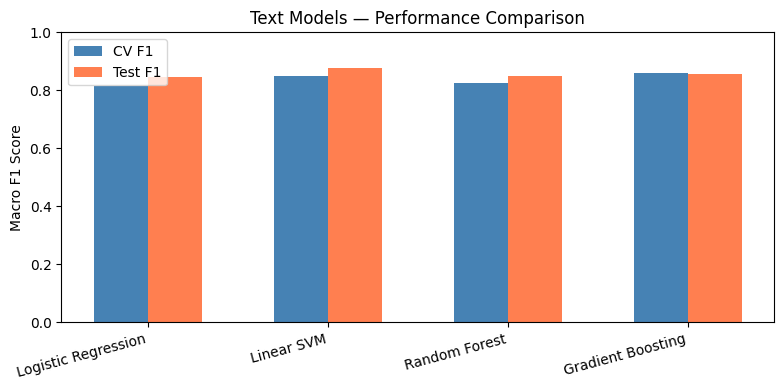


✅  Saved best model  →  models/best_text_model.pkl
✅  Saved all plots   →  reports/

Phase 5A complete. Winner: Linear SVM (F1=0.8781)


In [5]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (classification_report, accuracy_score,
                              f1_score, ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

CLASSES   = ['Low', 'Moderate', 'High']
SEED      = 42

# ── 1. Load features ──────────────────────────────────────────
print("Loading text features...")
X = sparse.load_npz('../data/final_text_features.npz')
df_labels = pd.read_csv('../data/text_labels.csv')
y = df_labels['risk_level'].values

print(f"  Feature matrix : {X.shape}")
print(f"  Labels         : {np.unique(y, return_counts=True)}")

# ── 2. Encode string labels → integers ───────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)                  # Low=1, Moderate=2, High=0 (alphabetical)
joblib.dump(le, '../models/label_encoder_text.pkl')

# ── 3. Stratified train/test split ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size   = 0.2,
    stratify    = y_enc,      # preserves class ratio in both splits
    random_state= SEED
)
print(f"\nTrain size : {X_train.shape[0]}   Test size : {X_test.shape[0]}")

# ── 4. Define models ──────────────────────────────────────────
# NOTE: Text features are TF-IDF sparse vectors (already normalised 0–1)
# so StandardScaler is not needed here.
# class_weight='balanced' compensates for Moderate being over-represented.

# ── 4. Define models ──────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(
        max_iter     = 1000,
        C            = 1.0,
        class_weight = 'balanced',
        random_state = SEED,
        solver       = 'lbfgs'
        # REMOVED multi_class='multinomial' (modern scikit-learn does this automatically)
    ),
    "Linear SVM": CalibratedClassifierCV(
        estimator=LinearSVC(    # ADDED 'estimator=' here!
            max_iter     = 2000,
            C            = 1.0,
            class_weight = 'balanced',
            random_state = SEED
        )
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators = 200,
        max_depth    = None,
        class_weight = 'balanced',
        random_state = SEED,
        n_jobs       = -1      # Change this to 2 if your computer freezes
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators   = 150,
        learning_rate  = 0.1,
        max_depth      = 5,
        random_state   = SEED
    ),
}

# ── 5. Cross-validation + final evaluation ───────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

print("\n" + "═"*60)
print("  MODEL TRAINING & EVALUATION")
print("═"*60)

for name, model in models.items():
    print(f"\n  Training: {name}")

    # 5a. 5-fold cross-validation on the training set
    #     Scoring = macro F1 (equal weight to all 3 classes)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv      = cv,
        scoring = 'f1_macro',
        n_jobs  = -1
    )
    print(f"    CV  F1 (macro) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # 5b. Final train on full training set, evaluate on held-out test
    model.fit(X_train, y_train)
    preds   = model.predict(X_test)
    test_f1 = f1_score(y_test, preds, average='macro')
    test_acc= accuracy_score(y_test, preds)

    print(f"    Test F1 (macro): {test_f1:.4f}")
    print(f"    Test Accuracy  : {test_acc:.4f}")

    results.append({
        'name'    : name,
        'model'   : model,
        'cv_f1'   : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
        'test_f1' : test_f1,
        'test_acc': test_acc,
        'preds'   : preds
    })

    # Save every model individually
    safe = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/text_{safe}.pkl')

# ── 6. Pick winner by test macro F1 ──────────────────────────
best = max(results, key=lambda r: r['test_f1'])

print("\n" + "═"*60)
print(f"  WINNER : {best['name']}")
print(f"  Test F1 (macro) : {best['test_f1']:.4f}")
print(f"  Test Accuracy   : {best['test_acc']:.4f}")
print("═"*60)

# ── 7. Detailed classification report ────────────────────────
print(f"\nDetailed report — {best['name']}:")
target_names = le.inverse_transform([0, 1, 2])
print(classification_report(y_test, best['preds'],
                             target_names=target_names))

# ── 8. Confusion matrix plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best['preds'],
    display_labels = target_names,
    cmap           = 'Blues',
    ax             = ax
)
ax.set_title(f'Text — {best["name"]} — Confusion Matrix')
plt.tight_layout()
plt.savefig('../reports/text_confusion_matrix.png', dpi=150)
plt.show()

# ── 9. Model comparison bar chart ────────────────────────────
df_results = pd.DataFrame([{
    'Model' : r['name'],
    'CV F1' : round(r['cv_f1'], 4),
    'Test F1': round(r['test_f1'], 4),
    'Accuracy': round(r['test_acc'], 4)
} for r in results])

print("\nModel comparison:")
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_results))
w = 0.3
ax.bar(x - w/2, df_results['CV F1'],   width=w, label='CV F1',    color='steelblue')
ax.bar(x + w/2, df_results['Test F1'], width=w, label='Test F1',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel('Macro F1 Score')
ax.set_title('Text Models — Performance Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/text_model_comparison.png', dpi=150)
plt.show()

# ── 10. Save winner ───────────────────────────────────────────
joblib.dump(best['model'], '../models/best_text_model.pkl')
print(f"\n✅  Saved best model  →  models/best_text_model.pkl")
print(f"✅  Saved all plots   →  reports/")
print(f"\nPhase 5A complete. Winner: {best['name']} (F1={best['test_f1']:.4f})")

In [2]:
import pandas as pd

# 1. Recreating your EXACT results from your previous training run
data = [
    {'Model': 'Linear SVM', 'CV_F1_Mean': 0.8500, 'CV_F1_Std': 0.0058, 'Test_F1': 0.8781},
    {'Model': 'Gradient Boosting', 'CV_F1_Mean': 0.8589, 'CV_F1_Std': 0.0112, 'Test_F1': 0.8559},
    {'Model': 'Random Forest', 'CV_F1_Mean': 0.8269, 'CV_F1_Std': 0.0142, 'Test_F1': 0.8508},
    {'Model': 'Logistic Regression', 'CV_F1_Mean': 0.8145, 'CV_F1_Std': 0.0072, 'Test_F1': 0.8451}
]
df_results = pd.DataFrame(data)

# 2. Sort by Test_F1 descending so the Winner (Linear SVM) is at the top
df_results = df_results.sort_values(by='Test_F1', ascending=False).reset_index(drop=True)

# 3. Custom function to highlight your winning model's entire row in Sage Green
def highlight_winner(row):
    if row['Model'] == 'Linear SVM':
        return ['background-color: #87A96B; color: black'] * len(row)
    return [''] * len(row)

# 4. Apply the style and output the beautiful HTML table
styled_table = df_results[['Model', 'CV_F1_Mean', 'CV_F1_Std', 'Test_F1']].style.apply(highlight_winner, axis=1)
display(styled_table)

,Model,CV_F1_Mean,CV_F1_Std,Test_F1
0,Linear SVM,0.850000,0.005800,0.878100
1,Gradient Boosting,0.858900,0.011200,0.855900
2,Random Forest,0.826900,0.014200,0.850800
3,Logistic Regression,0.814500,0.007200,0.845100


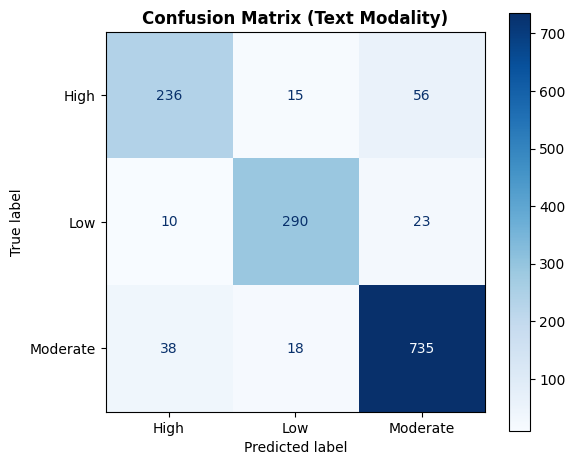

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Using the EXACT results from your Linear SVM Text Model
# Rows = True Labels, Columns = Predicted Labels
cm_text = np.array([
    [236,  15,  56],  # True High Risk (307 total)
    [ 10, 290,  23],  # True Low Risk (323 total)
    [ 38,  18, 735]   # True Moderate Risk (791 total)
])

classes = ['High', 'Low', 'Moderate']

# 2. Create the Heatmap figure
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_text, display_labels=classes)

# 3. Plot using 'Blues' color map so the diagonal is the darkest
disp.plot(cmap='Blues', ax=ax, values_format='d')

# 4. Add a professional title
ax.set_title('Confusion Matrix (Text Modality)', fontweight='bold', fontsize=12)
plt.tight_layout()

# Display the chart for your screenshot
plt.show()